# Statistique bivariée

Analyse de la relation entre deux variables

In [3]:
# importation des biblios necessaires 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set(style="whitegrid")
except:
    sns = None
    
# chargement du jeu de données 
df = pd.read_csv("ecommerce_dataset.csv")
df.head()


,client_id,sexe,âge,revenu_mensuel,segment_age,revenu_cat,produit,canal_achat,montant_panier,panier_frequent,note_satisfaction,retour_produit,date_achat
0,1,Homme,50,3893.70,Mature,Moyen,Sport,Mobile,83.27,Non,2,Non,2023-05-28
1,2,Femme,39,2885.15,Adulte,Moyen,Électronique,Mobile,47.18,Oui,3,Non,2023-01-13
2,3,Homme,44,2369.53,Mature,Moyen,Sport,Mobile,72.28,Oui,4,Non,2023-03-13
3,4,Homme,38,3197.92,Adulte,Moyen,Électronique,Mobile,54.59,Non,3,Non,2023-05-07
4,5,Homme,20,3774.66,Jeune,Moyen,Sport,Mobile,75.30,Non,4,Non,2023-07-04


## Les Analyses Bivariées 

| Relation | Exemple | Indicateurs |Test | Graphiques |
|---------|---------|-------------|------------|-------------|
| Quantitative / Quantitative | revenu_mensuel / montant_panier | covariance, corrélation  |  coeff Pearson (sensible aux outliers), Spearman, tau de Kendall  | scatter plot |
| Qualitative/Quantitative (2 modalités) | sexe ↔ montant_panier | moyennes par groupe |t de Student (indépendants avec des variances similaires), test U (non paramétriques)| boxplot, violin plot |
| Qualitative/Quantitative (3+ modalités) | segment_age ↔ montant_panier | moyennes par groupe |ANOVA (parametriques), Kruskal-Wallis (np)| boxplot, barplot |
|  Qualitative /Qualitative | sexe ↔ retour_produit | tableau de contingence | Khi-deux, Fisher (2x2), V de Cramér | countplot, heatmap |

#  CAS 1 : Quantitative / Quantitative

**Exemple : revenu_mensuel / montant_panier**
**Exemple : revenu_mensuel / montant_panier**

*Variables* : revenu_mensuel (X), montant_panier (Y)    
*Indicateurs* : Covariance, Corrélation 
*Test* : Pearson + regression (lineaire), Spearman (monotone), Kendall (robuste)
*Graphique* : Scatter plot   
*Objectif* : Voir la force et le sens de la relation  

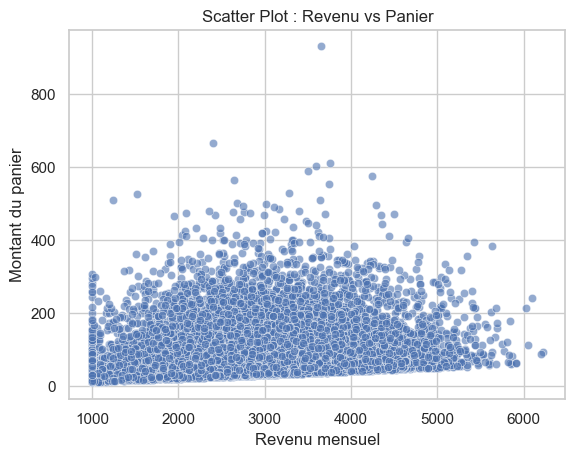

In [4]:
import numpy as np
from scipy import stats

# Variables quantitatives
x = df["revenu_mensuel"]
y = df["montant_panier"]


plt.figure()
if sns: sns.scatterplot(x=x, y=y, alpha=0.6)
else: plt.scatter(x, y, alpha=0.6)
plt.xlabel("Revenu mensuel")
plt.ylabel("Montant du panier")
plt.title("Scatter Plot : Revenu vs Panier")
plt.show()

In [6]:
# covariance
cov_xy = np.cov(x, y, ddof=1)[0, 1]

# crrélation de Pearson
pearson_r, pearson_p = stats.pearsonr(x, y)

# corrélation de Spearman
spearman_rho, spearman_p = stats.spearmanr(x, y)

# correlation de Kendall
kendall_tau, kendall_p = stats.kendalltau(x, y)

print(" Covariance :", cov_xy)
print(f" Corrélation de Pearson : r = {pearson_r:.3f} (p = {pearson_p:.3e})")
print(f" Corrélation de Spearman : ρ = {spearman_rho:.3f} (p = {spearman_p:.3e})")
print(f" Corrélation de Kendall : τ = {kendall_tau:.3f} (p = {kendall_p:.3e})")


 Covariance : 7974.862474043824
 Corrélation de Pearson : r = 0.139 (p = 8.627e-66)
 Corrélation de Spearman : ρ = 0.209 (p = 3.977e-147)
 Corrélation de Kendall : τ = 0.143 (p = 5.134e-151)


### Interprétation 

- Signe de la corrélation → sens de la relation (positive / négative)
- Valeur absolue → force de la relation (tres faible [0.00 – 0.19] /faible [0.20 – 0.39]/ modérée [0.40 – 0.59]/ forte[0.60 – 0.79]/ très forte [0.80 – 1.00])   
*Ces seuils sont arbitraires. En fonction de la discipline de recherche (ss, sciences de la santé, sciences physiques, etc.) et des variables à l’étude, l’interprétation de valeur de corrélation peut changer.*
- p-valeur → significativité statistique (H0,H1)
- Le coefficient de corrélation au carré = coeff de détermination (R²) → quantifie la variance partagée

##  À retenir

- La **covariance** indique seulement si X et Y varient **dans le même sens**.  
- Les **corrélations** normalisent la covariance et deviennent **comparables** et **interprétables**.  
- **Pearson** = linéaire (parametrique), **Spearman** = monotone (non parametrique), **Kendall** = robuste (non parametrique).

*Autres coeff (Biweight midcorrelation, Percentage bend correlation et pi de Shepherd*